# Netflix Stock Analysis Project 

In [2]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.1 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 4.3 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 4.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 4.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.3 MB 5.6 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [8]:
df=pd.read_csv("NFLX.csv")

In [10]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [11]:
sns.set(rc={'figure.figsize':(10,5)})

In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df= df.set_index('Date')
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


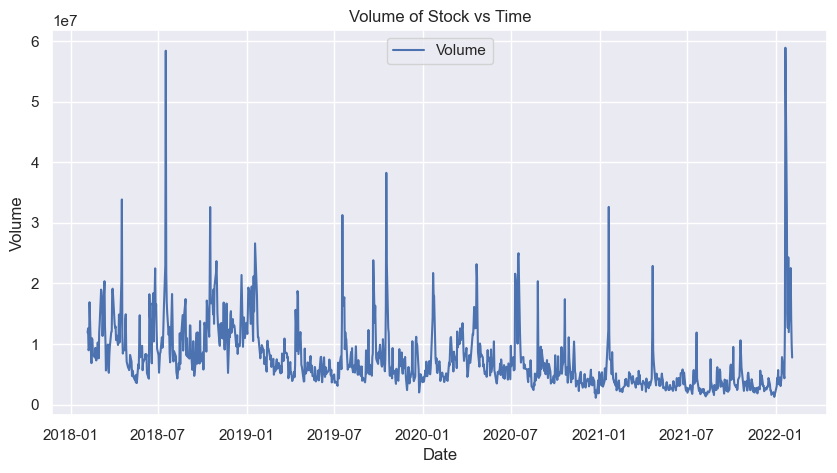

In [14]:
sns.lineplot(x=df.index, y=df['Volume'],label= 'Volume')
plt.title('Volume of Stock vs Time')
plt.show()

<Axes: title={'center': 'Netflix Stock Pice'}, xlabel='Date'>

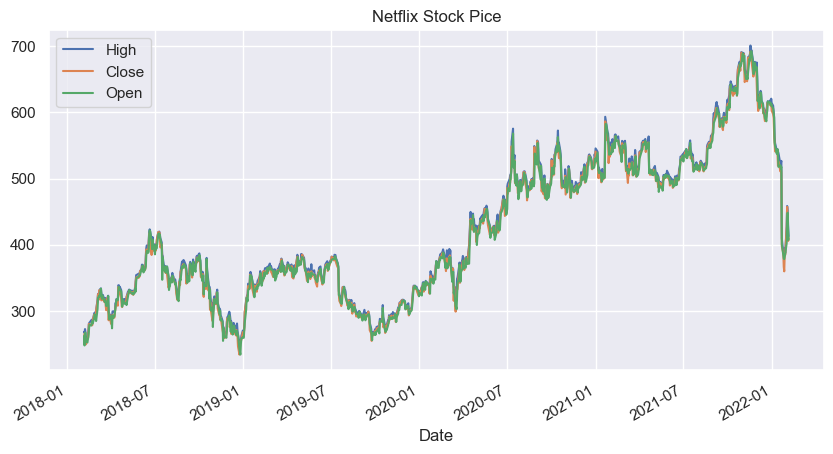

In [15]:
df.plot(y=['High', 'Close', 'Open'], title='Netflix Stock Pice')


<Axes: xlabel='Year'>

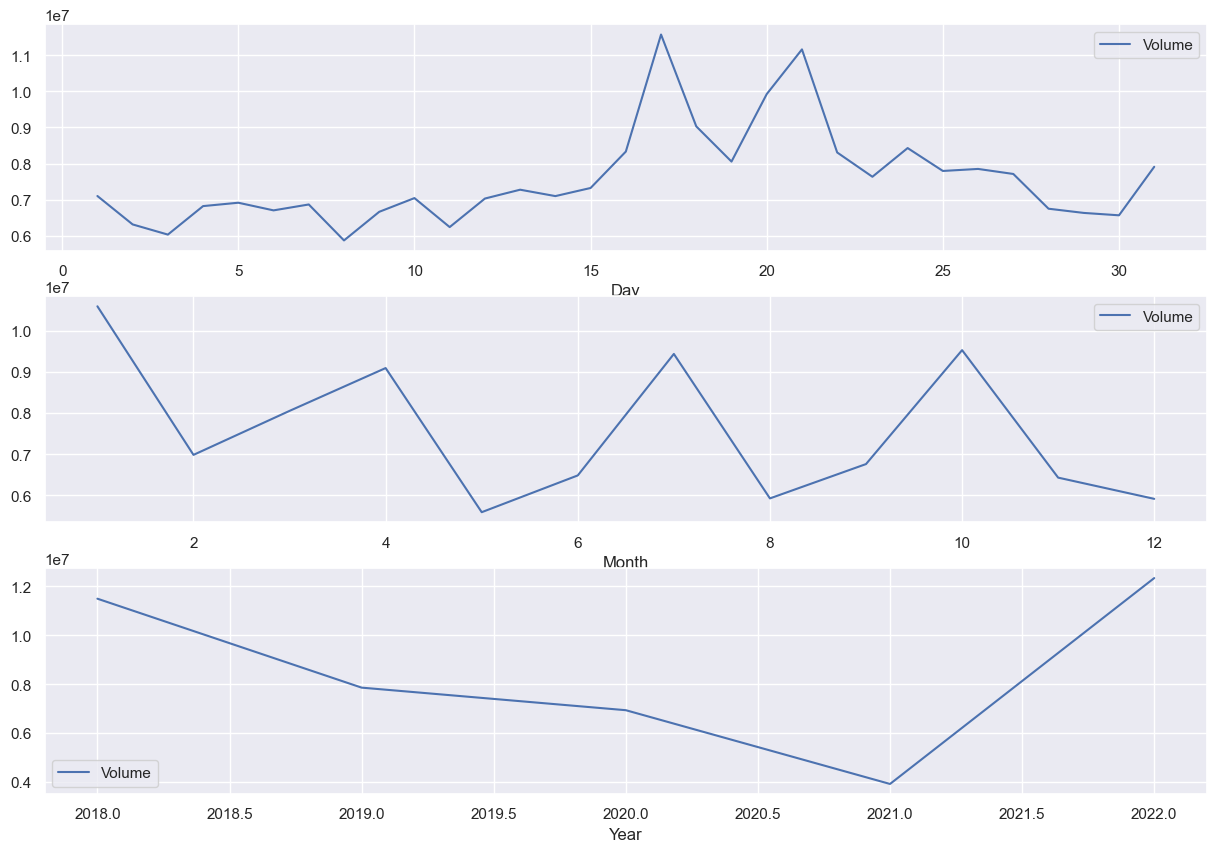

In [25]:
fig, (ax1,ax2,ax3)= plt.subplots(3, figsize =(15,10))
df.groupby(df.index.day).mean().plot(y= 'Volume', ax=ax1, xlabel ='Day')
df.groupby(df.index.month).mean().plot(y= 'Volume', ax=ax2, xlabel ='Month')
df.groupby(df.index.year).mean().plot(y= 'Volume', ax=ax3, xlabel ='Year')

# Dates with Highest stock Price

In [28]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...
2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000


In [29]:
a=df.sort_values(by = 'High', ascending = False).head(5)
a['High']

Date
2021-11-17    700.989990
2021-11-19    694.159973
2021-11-18    691.739990
2021-10-29    690.969971
2021-11-01    689.969971
Name: High, dtype: float64

In [34]:
b=df.sort_values(by = 'Low', ascending = True).head(5)
b['Low']

Date
2018-12-26    231.229996
2018-12-24    233.679993
2018-02-09    236.110001
2018-12-27    240.100006
2018-12-21    241.289993
Name: Low, dtype: float64

<Axes: xlabel='Date', ylabel='Low'>

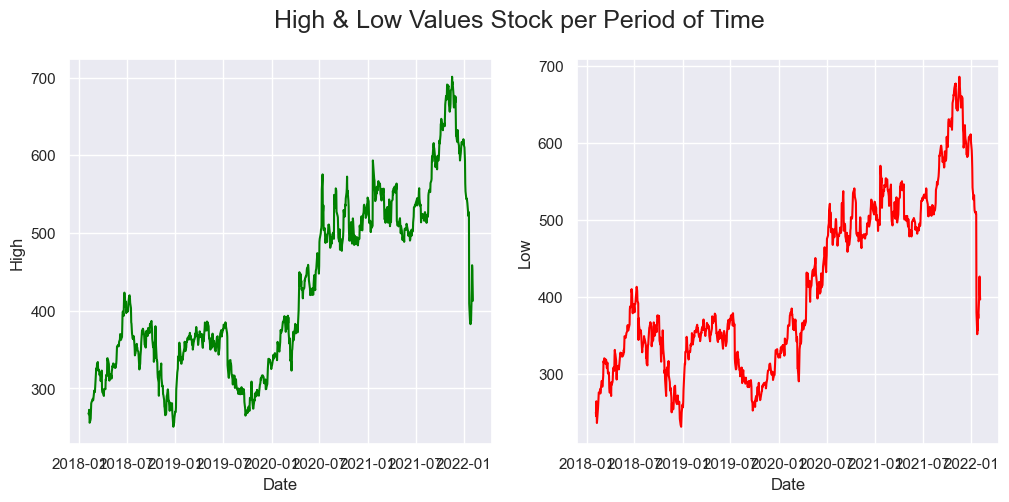

In [49]:
fig,axes = plt.subplots(nrows =1, ncols=2, sharex= True, figsize= (12,5))
fig.suptitle('High & Low Values Stock per Period of Time', fontsize = 18)
sns.lineplot(ax= axes[0], y =df['High'], x= df.index, color = 'green')
sns.lineplot(ax= axes[1], y =df['Low'], x= df.index, color = 'red')

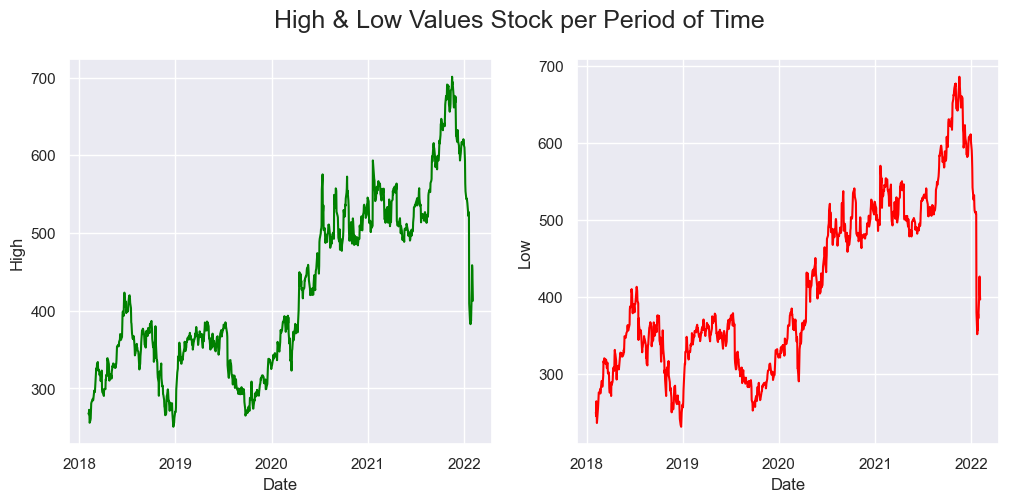

In [50]:
import matplotlib.dates as mdates

# 1. Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(12, 5))
fig.suptitle('High & Low Values Stock per Period of Time', fontsize=18)

# 2. Plot High and Low
sns.lineplot(ax=axes[0], y=df['High'], x=df.index, color='green')
sns.lineplot(ax=axes[1], y=df['Low'], x=df.index, color='red')

# 3. Update x-axis to show ONLY the Year
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())      # Find the start of each year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Display only the 'YYYY' format

plt.show()